In [3]:
import os
import re
import numpy as np
import pandas as pd
import datetime
import time
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

In [4]:
# File Paths
current_dir = os.getcwd()
data_path = f"{current_dir}/raw data"
ma_path = f"{data_path}/MA"
ny_path = f"{data_path}/NY"
sector_paths = ["FI", "HSA", "IN", "PST", "RT"]
platforms = ["glassdoor", "indeed", "linkedin"]

In [5]:
# retrieve baseline dataset
baseline_dataset_filepath = f"{data_path}/master_dataset.csv"
baseline_dataset_df = pd.read_csv(baseline_dataset_filepath)

baseline_df = baseline_dataset_df.copy()
print(len(baseline_df))

64796


In [ ]:
# Variable Breakdowns

In [7]:
baseline_df['job_level'].value_counts()

job_level
mid-senior level    6795
entry level         6759
not applicable      3301
director            1039
associate            955
executive            423
internship           317
Name: count, dtype: int64

In [42]:
baseline_df['job_type'].value_counts()

job_type
fulltime                                               36766
parttime                                                6032
parttime, fulltime                                      1556
contract                                                1057
internship                                               548
perdiem                                                  408
temporary                                                226
other                                                    117
fulltime, contract                                        88
fulltime, internship                                      73
temporary, fulltime                                       64
parttime, fulltime, perdiem                               56
fulltime, perdiem                                         54
volunteer                                                 37
parttime, contract                                        33
parttime, perdiem                                         32
parttime, fullt

In [33]:
baseline_df['interval'].value_counts()

interval
yearly     23065
hourly     18124
weekly       349
monthly       99
daily         51
Name: count, dtype: int64

In [34]:
baseline_df['is_remote'].value_counts()

is_remote
False    57627
True      7169
Name: count, dtype: int64

In [38]:
baseline_df['company'].value_counts()

company
JPMorganChase               793
Deloitte                    724
Domino's                    566
CVS Health                  504
Beth Israel Lahey Health    449
                           ... 
Hire Society                  1
Connecticut Innovations       1
GardaWorld                    1
Wawa, Inc.                    1
Lidl US                       1
Name: count, Length: 16686, dtype: int64

In [ ]:
# DATA OPERATIONALIZATION - GENERAL VARIABLES

In [101]:
wo_indicators_df = baseline_df.copy()

In [102]:
# operationalize by sector
for sector in sector_paths:
    wo_indicators_df.loc[wo_indicators_df['sector'] == sector, sector.lower()] = 1
    wo_indicators_df.loc[wo_indicators_df['sector'] != sector, sector.lower()] = 0

# operationalize by market
wo_indicators_df.loc[wo_indicators_df['market'] == "NY", "ny_msa"] = 1
wo_indicators_df.loc[wo_indicators_df['market'] != "NY", "ny_msa"] = 0

wo_indicators_df.loc[wo_indicators_df['market'] == "MA", "bos_msa"] = 1
wo_indicators_df.loc[wo_indicators_df['market'] != "MA", "bos_msa"] = 0

# operationalize by site
for platform in platforms:
    wo_indicators_df.loc[wo_indicators_df['site'] == platform, platform] = 1
    wo_indicators_df.loc[wo_indicators_df['site'] != platform, platform] = 0

In [103]:
# operationalize salary by pay interval
intervals = ["yearly", "hourly", "weekly", "monthly", "daily"]
for interval in intervals:
    wo_indicators_df.loc[wo_indicators_df['interval'] == interval, f"int_{interval}"] = 1
    wo_indicators_df.loc[wo_indicators_df['interval'] != interval, f"int_{interval}"] = 0

# operationalize whether a job posting is sponsored or organic
wo_indicators_df.loc[wo_indicators_df['listing_type'] == "sponsored", "sponsored"] = 1
wo_indicators_df.loc[wo_indicators_df['listing_type'] != "sponsored", "sponsored"] = 0

# operationalize whether a job is remote
wo_indicators_df.loc[wo_indicators_df['is_remote'] == True, "remote"] = 1
wo_indicators_df.loc[wo_indicators_df['is_remote'] == False, "remote"] = 0

In [104]:
# operationalize job type
job_types = ["fulltime", "parttime", "contract", "internship", "temporary"]
for job_type in job_types:
    wo_indicators_df.loc[wo_indicators_df['job_type'] == job_type, f"jt_{job_type}"] = 1
    wo_indicators_df.loc[wo_indicators_df['job_type'] != job_type, f"jt_{job_type}"] = 0

# operationalize job level
job_levels = ["mid-senior level", "entry level", "director", "associate", "executive", "internship"]
wo_indicators_df.loc[wo_indicators_df['job_level'].isna(), "job_level_na"] = 1
wo_indicators_df.loc[wo_indicators_df['job_level'].notna(), "job_level_na"] = 0
wo_indicators_df.loc[wo_indicators_df['job_level'] == "not applicable", "job_level_na"] = 1

for job_level in job_levels:
    wo_indicators_df.loc[wo_indicators_df['job_level'] == job_level, f"job_level_{job_level}"] = 1
    wo_indicators_df.loc[wo_indicators_df['job_level'] != job_level, f"job_level_{job_level}"] = 0

In [ ]:
# DATA OPERATIONALIZATION - GHOST JOB INDICATORS

In [82]:
today = datetime.datetime.now().strftime("%Y-%m-%d")
today_date_obj = datetime.datetime.strptime(today, "%Y-%m-%d")
listing_age_days = []
listing_ages = []

for i in range(len(wo_indicators_df)):
    date_posted = datetime.datetime.strptime(wo_indicators_df.at[i, 'date_posted'], "%Y-%m-%d")
    listing_age = today_date_obj - date_posted
    days_old = int(str(listing_age).split(" ")[0])
    listing_age_days.append(days_old)

    weeks_old = days_old // 7
    listing_ages.append(weeks_old)

wo_indicators_df = wo_indicators_df.assign(listing_age_days = listing_age_days, listing_age = listing_ages)

wo_indicators_df['listing_age'].value_counts()

listing_age
5    23123
4    21867
3    11815
6     7984
2        7
Name: count, dtype: int64

In [84]:
w_indicators_df = wo_indicators_df.copy()

In [85]:
# operationalize salary information as categorical variable
w_indicators_df.loc[w_indicators_df['min_amount'].isna(), 'no_salary'] = 1 # missing salary
w_indicators_df.loc[w_indicators_df['min_amount'].notna(), 'no_salary'] = 0

w_indicators_df.loc[w_indicators_df['min_amount'] != w_indicators_df['max_amount'], 'range_salary'] = 1 # salary provided as a range
w_indicators_df.loc[w_indicators_df['min_amount'] == w_indicators_df['max_amount'], 'range_salary'] = 0
w_indicators_df.loc[w_indicators_df['no_salary'] == True, 'range_salary'] = 0

w_indicators_df.loc[w_indicators_df['min_amount'] == w_indicators_df['max_amount'], 'base_salary'] = 1 # salary provided as a single value
w_indicators_df.loc[w_indicators_df['min_amount'] != w_indicators_df['max_amount'], 'base_salary'] = 0
w_indicators_df.loc[w_indicators_df['range_salary'] == True, 'base_salary'] = 0

# operationalize link to company website as a binary variable
w_indicators_df.loc[w_indicators_df['job_url_direct'].isna(), 'link_to_company_web'] = 1
w_indicators_df.loc[w_indicators_df['job_url_direct'].notna(), 'link_to_company_web'] = 0 

In [86]:
# operationalize description specificity variable
reporting_keywords = ["report to", "department"]
timeline_keywords = ["start date", "hiring immediately", "applications close"]
w_indicators_df.loc[w_indicators_df['description'].str.contains('|'.join(reporting_keywords), case=False, na=False), 'desc_report'] = 1
w_indicators_df.loc[w_indicators_df['desc_report'].isna(), 'desc_report'] = 0
w_indicators_df.loc[w_indicators_df['description'].str.contains('|'.join(timeline_keywords), case=False, na=False), 'desc_timeline'] = 1
w_indicators_df.loc[w_indicators_df['desc_timeline'].isna(), 'desc_timeline'] = 0

In [116]:
# operationalize requirements to responsibilities ratio
test_sample = baseline_df.sample(n=5).reset_index(drop=True)
test_sample.head(5)

,id,site,job_url,job_url_direct,title,company,location,date_posted,job_type,salary_source,interval,min_amount,max_amount,is_remote,job_level,job_function,listing_type,description,company_industry,company_num_employees,company_revenue,sector,occupation,market,date_scraped
0,li-4384580625,linkedin,https://www.linkedin.com/jobs/view/4384580625,NaN,"Medical Assistant - Float - South Shore, Boston, MA",Gather Health,"Quincy, MA",2026-03-12,fulltime,NaN,NaN,NaN,NaN,False,entry level,Health Care Provider,NaN,**Description**\n**Who is Gather Health?**\n We are a new and growing healthcare organization wi...,Hospitals and Health Care,NaN,NaN,HSA,MAS,MA,2026-03-14
1,li-4306818817,linkedin,https://www.linkedin.com/jobs/view/4306818817,https://jobs.newellbrands.com/job/Somerville-Yankee-Candle-Retail-Seasonal-Sales-Associate-Somer...,"Yankee Candle - Retail Seasonal Sales Associate - Somerville, MA",Newell Brands,"Somerville, MA",2026-03-14,parttime,NaN,NaN,NaN,NaN,False,entry level,Sales and Business Development,NaN,**Job ID:** \n 6769\n \n\n \n\n**Alternate Locations:**\n**Newell Brands** \n is a leading co...,Manufacturing,NaN,NaN,RT,RSP,MA,2026-03-16
2,in-d591c6d455773fab,indeed,https://www.indeed.com/viewjob?jk=d591c6d455773fab,https://hcrb.fa.us2.oraclecloud.com/hcmUI/CandidateExperience/en/sites/CX/requisitions/preview/1...,Internal Audit Co-op,The Boston Beer Company,"Boston, MA, US",2026-03-10,fulltime,direct_data,hourly,18.0,20.0,False,NaN,NaN,NaN,"We are currently hiring an Internal Audit Co\\-op in Boston MA. This is a 6\\-month co\\-op, run...",NaN,"1,001 to 5,000",$1B to $5B (USD),PST,AAA,MA,2026-03-11
3,in-fd5d56060469bbde,indeed,https://www.indeed.com/viewjob?jk=fd5d56060469bbde,https://apply.jobappnetwork.com/clients/15879/posting/10425782/en?src=indeed&dt=0326&utm_source=...,Assistant General Manager,Burger King,"Saddle Brook, NJ, US",2026-03-06,fulltime,direct_data,hourly,18.0,20.0,False,NaN,NaN,NaN,**ASSISTANT MANAGER**\n\n**Carrols LLC is the largest Burger King Franchise. We own and operate ...,NaN,"10,000+",Decline to state,PST,GOM-PST,NY,2026-03-08
4,in-be836cadf4555f92,indeed,https://www.indeed.com/viewjob?jk=be836cadf4555f92,https://jobs.tenethealth.com/job/-/-/1127/92956257520,Registered Nurse (RN) - Operating Room,Tenet Healthcare,"Framingham, MA, US",2026-03-19,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,### **Overview**\n\n \n\n﻿\nJoin our dedicated healthcare team where compassion meets innovatio...,Health Care,"10,000+",$5B to $10B (USD),HSA,RN,MA,2026-03-20


In [292]:
import re
test = baseline_df.sample(n=1).reset_index(drop=True)
desc = test.at[0, 'description']
print(desc)

Senior Oracle APEX Developer
Employment Type: Full\\-Time, Entry\\-Mid Level
Department: Information Technology

CGS is hiring a Senior Oracle APEX Developer to support a range of IT services, including software application support, enterprise infrastructure support, service desk, ITSM, deskside support, workstation engineering and maintenance, telecommunications and mobility engineering services, managed print services, Active Directory services, and video conferencing. The ideal candidate will be personable and articulate and will focus on making sure that the customer’s needs are met quickly and effectively. The successful candidate will be a self\\-starter who can work with limited supervision. Excellent communication skills are required to effectively interface with customers to understand requirements and mission needs, and then be able to translate them into actions.

CGS brings motivated, highly skilled, and creative people together to solve the government’s most dynamic proble

In [316]:
reporting_keywords = ["report to", "department"]
timeline_keywords = ["start date", "hiring immediately", "applications close"]
rep_keywords_df = baseline_df[baseline_df['description'].str.contains('|'.join(reporting_keywords), case=False, na=False)]
rep_result = rep_keywords_df.groupby(['site']).count()
display("test: ", rep_result)

'test: '

,id,job_url,job_url_direct,title,company,location,date_posted,job_type,salary_source,interval,min_amount,max_amount,is_remote,job_level,job_function,listing_type,description,company_industry,company_num_employees,company_revenue,sector,occupation,market,date_scraped
site,,,,,,,,,,,,,,,,,,,,,,,,
glassdoor,3734,3734,0,3734,3734,3734,3734,0,3648,3648,3648,3648,3734,0,0,3734,3734,0,0,0,3734,3734,3734,3734
indeed,9643,9643,9643,9643,9643,9643,9643,8076,7221,8554,7221,7221,9643,0,0,0,9643,3264,7685,6801,9643,9643,9643,9643
linkedin,5734,5734,1637,5734,5734,5734,5734,5734,161,161,161,161,5734,5734,5732,0,5734,5734,0,0,5734,5734,5734,5734


In [317]:
timeline_keywords = ["start date", "hiring immediately", "applications close"]
time_keywords_df = baseline_df[baseline_df['description'].str.contains('|'.join(timeline_keywords), case=False, na=False)]
time_result = time_keywords_df.groupby(['site']).count()
display("test: ", time_result)

'test: '

,id,job_url,job_url_direct,title,company,location,date_posted,job_type,salary_source,interval,min_amount,max_amount,is_remote,job_level,job_function,listing_type,description,company_industry,company_num_employees,company_revenue,sector,occupation,market,date_scraped
site,,,,,,,,,,,,,,,,,,,,,,,,
glassdoor,287,287,0,287,287,287,287,0,266,266,266,266,287,0,0,287,287,0,0,0,287,287,287,287
indeed,868,868,868,868,868,868,868,757,500,736,500,500,868,0,0,0,868,422,716,652,868,868,868,868
linkedin,708,708,237,708,708,708,708,708,10,10,10,10,708,708,707,0,708,708,0,0,708,708,708,708


In [334]:
resp_keywords = ["what you'll do", "Skills", "Responsibilities", "Duties", "Role Overview", "Position Details", "Essential Functions"]
req_keywords = ["what you'll need", "what you'll bring", "Skills", "Requirements", "Qualifications", "competencies"]
pref_keywords = ["nice to have", "bonus", "preferred", "ideal"]
resp_keywords_df = baseline_df[baseline_df['description'].str.contains('|'.join(resp_keywords), case=True, na=False)]
resp_result = resp_keywords_df.groupby(['site'])['interval'].count()
display("test: ", resp_result)

'test: '

site
glassdoor     7224
indeed       17668
linkedin       404
Name: interval, dtype: int64

In [338]:
# in-e8cc8c77e1a65639

def keyword_match(job_desc, keywords):
    res = ""
    kw_loc = -1
    for kw in keywords:
        if kw in job_desc:
            kw_loc = re.search(kw, job_desc).end()
            jd_splits = desc.partition(kw)
            res = jd_splits[2]
    return [kw_loc, res]
    
def parse_jd():
    print()
            

# desc = desc.replace("**", "")
desc = test.at[0, 'description']

try_test = desc.split("\n*")
print(try_test)
# resp = keyword_match(desc, resp_keywords)
# if resp[0] == -1:
#     req = keyword_match(desc, req_keywords)
# else:
#     input = resp[1]
#     req = keyword_match(input[resp[0]:], req_keywords)

# if req[0] == -1:
#     req = keyword_match(desc, pref_keywords)
# else:
#     input = req[1]
#     pref = keyword_match(input[req[0]:], pref_keywords)

# # print(desc)
# print(resp)
# print(req)
# print(pref)


# s = desc.partition("Skills")
# q = s[2].partition("Qualifications")
# e = q[2].partition("\n\n")
# print(e[0])
# print(q[0])
# req = re.search("Requirements", desc)
# resp = re.search("Responsibilities", desc)

# resp_items = desc[resp.end():req.start()]
# req_items = desc[req.start():]
# req_items = desc[req.start():]

# resps = re.findall(r"\*", resp_items)
# print(len(resps), resps)
# reqs = re.findall(r"\*", req_items)
# print(len(reqs), reqs)

# print(resp_items)
# print(req_items)


['Senior Oracle APEX Developer\nEmployment Type: Full\\\\-Time, Entry\\\\-Mid Level\nDepartment: Information Technology\n\nCGS is hiring a Senior Oracle APEX Developer to support a range of IT services, including software application support, enterprise infrastructure support, service desk, ITSM, deskside support, workstation engineering and maintenance, telecommunications and mobility engineering services, managed print services, Active Directory services, and video conferencing. The ideal candidate will be personable and articulate and will focus on making sure that the customer’s needs are met quickly and effectively. The successful candidate will be a self\\\\-starter who can work with limited supervision. Excellent communication skills are required to effectively interface with customers to understand requirements and mission needs, and then be able to translate them into actions.\n\nCGS brings motivated, highly skilled, and creative people together to solve the government’s most 

In [198]:
import re
regex_bullets = r"\*[a-zA-Z]+"
for i in range(len(test_sample)):
    desc = test_sample.at[i, 'description']
    match = re.search("Requirements", desc)
    req_sub = desc[match.end():]
    bullet_point = re.search(r"\*", req_sub)
    req_sub = req_sub[bullet_point.start():]
    bullets = re.findall(regex_bullets, req_sub)
    # print(req_sub[bullet_point.start():])
    print(bullets)
    print(desc)
    break

['*What', '*What', '*Why', '*Gather', '*All']
**Description**
**Who is Gather Health?**
 We are a new and growing healthcare organization with a unique and innovative approach to healthcare. Our mission is to improve lives and communities through socially supported primary care for older adults. Our innovative business model allows our clinicians to treat the whole patient \\- not just their clinical needs. We do this by having a dedicated care team that supports our clinicians by addressing our patients’ social determinants of health and providing the highest quality of service possible. Our ultimate vision is creating generational health and equity for communities across the country, one patient at a time.
   

  

**What are the duties of the Medical Assistant?**
**Duties**
 The Medical Assistant will be part of the care\\-team which consists of physicians, advanced practice providers, medical technicians, and patient liaisons. The MA position has been newly created to support the g

In [84]:
desc_sample = baseline_df.sample(n=50).reset_index(drop=True)
desc_sample.head(50)

,id,site,job_url,job_url_direct,title,company,location,date_posted,job_type,salary_source,interval,min_amount,max_amount,is_remote,job_level,job_function,listing_type,description,company_industry,company_num_employees,company_revenue,sector,occupation,market,date_scraped
0,li-4367358249,linkedin,https://www.linkedin.com/jobs/view/4367358249,NaN,Managing Director,AKAM,"New York, NY",2026-03-14,fulltime,NaN,NaN,NaN,NaN,False,director,Business Development and Sales,NaN,**About AKAM:** \n AKAM is a leading property management firm serving some of the most prestigio...,Real Estate,NaN,NaN,IN,PAD,NY,2026-03-16
1,gd-1010063009304,glassdoor,https://www.glassdoor.com/job-listing/j?jl=1010063009304,NaN,"Associate (or Analyst), Bank Lines",Golub Capital,"New York, NY",2026-03-12,NaN,direct_data,yearly,165000.0,175000.0,False,NaN,NaN,organic,Position Information\nHiring Manager:\nManaging Director\nDepartment:\nStructured Products\nDepa...,NaN,NaN,NaN,FI,FIA,NY,2026-03-12
2,in-409312e285795640,indeed,https://www.indeed.com/viewjob?jk=409312e285795640,https://jobs.cvviz.com/share_community_development_corporation/job_80249_Regional_Growth_Manager...,Regional Growth Manager - Sales and Marketing (Remote),SHARE Community Development Corporation,"Newark, NJ, US",2026-03-17,"parttime, fulltime",NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,**Regional Growth Manager \\- Sales \\& Marketing (Remote)** **W\\-2 \\| UNCAPPED 100% COMMISSIO...,NaN,NaN,NaN,IN,MRS,NY,2026-03-18
3,li-4378649558,linkedin,https://www.linkedin.com/jobs/view/4378649558,NaN,Financial Planning Analyst (On-Site),Longroad Energy,"Boston, MA",2026-03-04,fulltime,NaN,NaN,NaN,NaN,False,entry level,Finance and Sales,NaN,"**Description**\n**About Longroad Energy**\n Longroad Energy is a Boston, MA headquartered renew...",Renewable Energy Semiconductor Manufacturing,NaN,NaN,FI,FM,MA,2026-03-06
4,li-4383635642,linkedin,https://www.linkedin.com/jobs/view/4383635642,https://myjobs.adp.com/stevemaddenretailcareers/cx/job-details?reqId=5001081471606&rb=LINKEDIN&u...,Sales Supervisor,Steve Madden,"East Rutherford, NJ",2026-03-14,fulltime,NaN,NaN,NaN,NaN,False,mid-senior level,Sales and Business Development,NaN,**Sales Supervisor (F/T)**\n The Sales Supervisor supports the management team and performs all ...,Retail,NaN,NaN,IN,SM,NY,2026-03-16
5,gd-1010061270925,glassdoor,https://www.glassdoor.com/job-listing/j?jl=1010061270925,NaN,Restaurant Operations Manager,First Watch Restaurants,"Woburn, MA",2026-03-11,NaN,direct_data,yearly,70000.0,75000.0,False,NaN,NaN,sponsored,"**NEW RESTAURANT COMING SOON TO WOBURN, MA!!!**\n\n**Overview**\n\n**Our YOU FIRST Philosophy**\...",NaN,NaN,NaN,IN,CIS,MA,2026-03-11
6,li-4379120155,linkedin,https://www.linkedin.com/jobs/view/4379120155,NaN,3P-11P Nursing Supervisor,Bartholomew Health Care Group Inc.,"Fall River, MA",2026-03-02,fulltime,NaN,NaN,NaN,NaN,False,entry level,Health Care Provider,NaN,"**Kimwell Nursing and Rehab** \n is looking for an enthusiastic, compassionate\n **Nursing 3P\\-...",Hospitals and Health Care,NaN,NaN,RT,GOM-RT,MA,2026-03-06
7,gd-1010065983052,glassdoor,https://www.glassdoor.com/job-listing/j?jl=1010065983052,NaN,"Infusion RN in Cambridge, MA",Soliant,"Cambridge, MA",2026-03-15,NaN,direct_data,hourly,26.0,45.0,False,NaN,NaN,sponsored,"***Nursing degree, active registered nurse (RN) license and minimum 1\\+ years Infusion RN exper...",NaN,NaN,NaN,HSA,RN,MA,2026-03-16
8,in-e1cd76ca182d88bc,indeed,https://www.indeed.com/viewjob?jk=e1cd76ca182d88bc,https://jobs.citizensbank.com/job/-/-/288/92387945792,Consumer Call Monitoring Manager,Citizens,"Johnston, RI, US",2026-03-04,fulltime,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,**Description**\n\n\nThe Call Monitoring Manager is responsible for leading and overseeing the c...,NaN,"10,000+",$5B to $10B (USD),FI,CSR-FI,MA,2026-03-07
9,gd-1010055064967,glassdoor,https://www.glassdoor.com/job-listing/j?jl=1010055064967,NaN,PROGRAM MANAGER - FINANCE & REVENUE MANAGEMENT,Wolters Kluwer,"New York, NY",2026-03-04,Na

In [87]:
# drop unneccessary columns for running regressions
cols_to_drop = ['description', 'site', 'job_url', 'job_url_direct', 'title', 'company', 'location', 'date_posted',
                'job_type', 'salary_source', 'interval', 'min_amount', 'max_amount', 'is_remote',
                'job_level', 'job_function', 'listing_type', 'company_industry', 'company_num_employees',
                'company_revenue', 'sector', 'occupation', 'market', 'date_scraped']
wo_indicators_df = wo_indicators_df.drop(cols_to_drop, axis=1, errors='ignore')
w_indicators_df = w_indicators_df.drop(cols_to_drop, axis=1, errors='ignore')

In [ ]:
# RUN MODELS

In [425]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Lasso, Ridge, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

In [534]:
listing_age = wo_indicators_df['listing_age']
listing_age_days = wo_indicators_df['listing_age_days']

wo_data = wo_indicators_df.copy()
cols = ['listing_age', 'listing_age_days', 'id']
wo_data = wo_data.drop(columns=cols)

y = listing_age_days
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wo_data)

X_scaled[:5]

array([[ 2.29833302, -0.61166642, -0.55417403, -0.52745056, -0.36215444,
        -1.16622473,  1.16622473,  2.03271984, -1.00566454, -0.65826883,
         1.3450941 , -0.62315893, -0.07358874, -0.0391179 , -0.02806609,
         3.69187473, -0.35270879, -1.14527991, -0.32038708, -0.12877598,
        -0.09235501, -0.05916145,  0.57946498, -0.34227643, -0.34126264,
        -0.12765677, -0.12230715, -0.08106219, -0.07011654],
       [ 2.29833302, -0.61166642, -0.55417403, -0.52745056, -0.36215444,
        -1.16622473,  1.16622473,  2.03271984, -1.00566454, -0.65826883,
        -0.74344241,  1.60472707, -0.07358874, -0.0391179 , -0.02806609,
         3.69187473, -0.35270879, -1.14527991, -0.32038708, -0.12877598,
        -0.09235501, -0.05916145,  0.57946498, -0.34227643, -0.34126264,
        -0.12765677, -0.12230715, -0.08106219, -0.07011654],
       [ 2.29833302, -0.61166642, -0.55417403, -0.52745056, -0.36215444,
        -1.16622473,  1.16622473,  2.03271984, -1.00566454, -0.65826883,
  

In [535]:
grid = 10 ** np.linspace(10, -2, 100)
grid[:5], grid[-5:]

(array([1.00000000e+10, 7.56463328e+09, 5.72236766e+09, 4.32876128e+09,
        3.27454916e+09]),
 array([0.03053856, 0.0231013 , 0.01747528, 0.01321941, 0.01      ]))

In [536]:
ridge_coefs = []
for a in grid:
    m = Ridge(alpha=a, fit_intercept=True)
    m.fit(X_scaled, y)
    ridge_coefs.append(m.coef_)

ridge_coefs = np.vstack(ridge_coefs)  # (n_alphas, n_features)
ridge_coefs.shape

(100, 29)

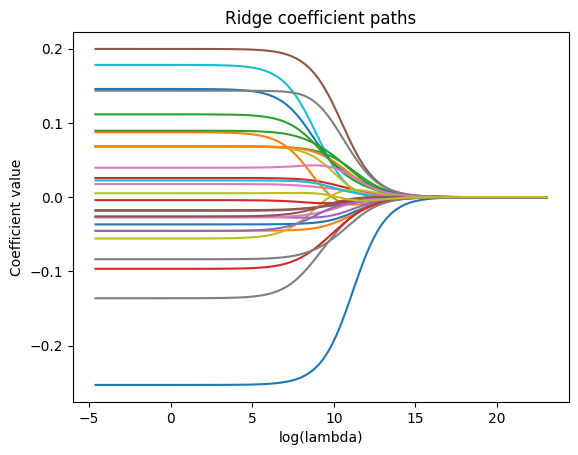

In [492]:
plt.figure()
for j in range(ridge_coefs.shape[1]):
    plt.plot(np.log(grid), ridge_coefs[:, j])
plt.xlabel("log(lambda)")
plt.ylabel("Coefficient value")
plt.title("Ridge coefficient paths")
plt.show()

In [537]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, listing_age_days, test_size=0.2, random_state=42, shuffle=True
)

X_train.shape, X_test.shape

((51836, 29), (12960, 29))

In [538]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)

# RidgeCV chooses alpha that minimizes CV error
ridge_cv = RidgeCV(alphas=grid, cv=kf, fit_intercept=True, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train, y_train)
best_alpha_ridge = ridge_cv.alpha_
best_alpha_ridge

np.float64(2154.4346900318824)

In [539]:
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_pred = ridge.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(38.855784474986095, 0.003505400677261794)

In [531]:
ridge_full_best = Ridge(alpha=best_alpha_ridge, fit_intercept=True).fit(X_scaled, y)
ridge_coefs = pd.Series(ridge_full_best.coef_, index=wo_data.columns).sort_values(ascending=False)
ridge_coefs

sponsored                     0.187025
jt_fulltime                   0.139874
linkedin                      0.136329
int_yearly                    0.112371
job_level_na                  0.093578
int_weekly                    0.082074
in                            0.066183
jt_temporary                  0.066018
jt_parttime                   0.063626
int_hourly                    0.056819
job_level_associate           0.041633
pst                           0.024454
jt_contract                   0.021587
bos_msa                       0.015912
job_level_internship          0.005685
int_monthly                  -0.006147
ny_msa                       -0.015912
rt                           -0.016568
job_level_director           -0.021255
remote                       -0.025379
int_daily                    -0.027476
fi                           -0.035973
job_level_entry level        -0.036203
indeed                       -0.036934
hsa                          -0.044225
job_level_executive      

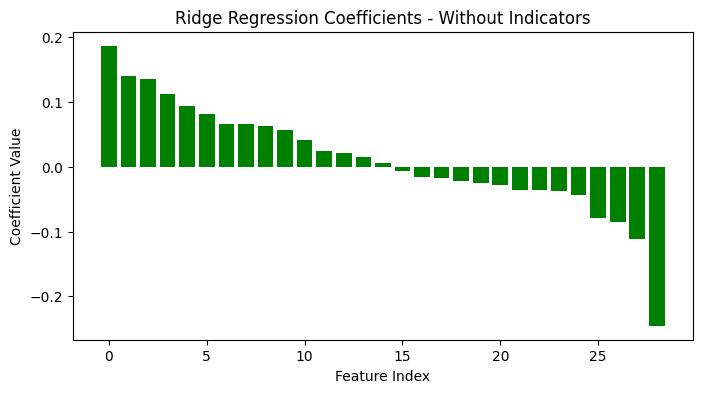

In [533]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(ridge_coefs)), ridge_coefs, color="green")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regression Coefficients - Without Indicators")
plt.show()

In [540]:
lasso_coefs = []
for a in grid:
    m = Lasso(alpha=a, fit_intercept=True, max_iter=200000)
    m.fit(X_train, y_train)
    lasso_coefs.append(m.coef_)
lasso_coefs = np.vstack(lasso_coefs)
lasso_coefs.shape

(100, 29)

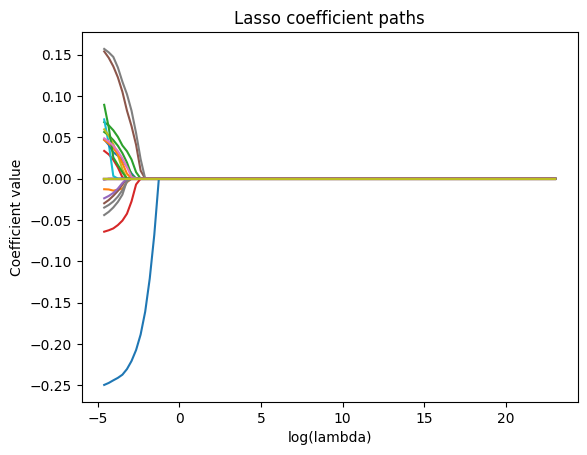

In [498]:
plt.figure()
for j in range(lasso_coefs.shape[1]):
    plt.plot(np.log(grid), lasso_coefs[:, j])
plt.xlabel("log(lambda)")
plt.ylabel("Coefficient value")
plt.title("Lasso coefficient paths")
plt.show()

In [541]:
lasso_cv = LassoCV(alphas=grid, cv=kf, fit_intercept=True, max_iter=200000, random_state=0)
lasso_cv.fit(X_train, y_train)

best_alpha_lasso = lasso_cv.alpha_
best_alpha_lasso

np.float64(0.01)

In [542]:
lasso = Lasso(alpha=best_alpha_lasso)
ridge.fit(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_pred = ridge.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(38.855784474986095, 0.003505400677261794)

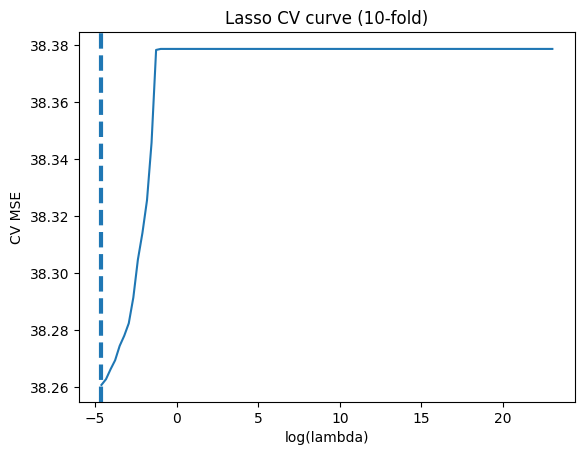

38.866042516246196

In [500]:
# CV curve (mean MSE vs log(lambda))
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure()
plt.plot(np.log(lasso_cv.alphas_), mean_mse)
plt.axvline(np.log(best_alpha_lasso), linestyle="--", linewidth=3)
plt.xlabel("log(lambda)")
plt.ylabel("CV MSE")
plt.title("Lasso CV curve (10-fold)")
plt.show()

lasso_best = Lasso(alpha=best_alpha_lasso, fit_intercept=True, max_iter=200000, random_state=0).fit(X_train, y_train)
mse_lasso_best = mean_squared_error(y_test, lasso_best.predict(X_test))
mse_lasso_best

In [501]:
lasso_full_best = Lasso(alpha=best_alpha_lasso, fit_intercept=True, max_iter=200000, random_state=0).fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_full_best.coef_, index=wo_data.columns).sort_values(ascending=False)
lasso_coefs

sponsored                     1.750468e-01
jt_fulltime                   1.225629e-01
job_level_na                  9.257453e-02
linkedin                      7.567528e-02
in                            7.388995e-02
int_weekly                    6.746839e-02
int_yearly                    5.657283e-02
jt_temporary                  5.607208e-02
job_level_associate           4.685460e-02
jt_parttime                   4.559855e-02
pst                           2.934552e-02
jt_contract                   9.296811e-03
job_level_internship          3.207805e-03
bos_msa                       3.665223e-15
job_level_director           -0.000000e+00
indeed                       -0.000000e+00
job_level_entry level        -0.000000e+00
int_hourly                    0.000000e+00
rt                           -0.000000e+00
int_monthly                  -1.922716e-04
remote                       -1.260034e-02
fi                           -1.599283e-02
ny_msa                       -1.724173e-02
hsa        

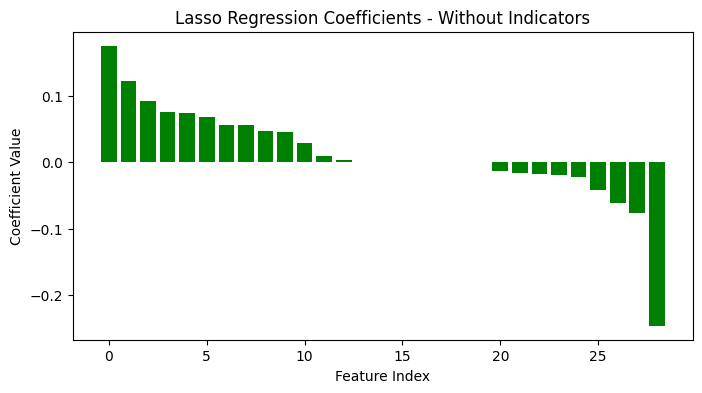

In [502]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(lasso_coefs)), lasso_coefs, color="green")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Coefficients - Without Indicators")
plt.show()

In [503]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, listing_age, test_size=0.2, random_state=42, shuffle=True
)

X_train.shape, X_test.shape

((51836, 29), (12960, 29))

In [504]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)

# RidgeCV chooses alpha that minimizes CV error
ridge_cv = RidgeCV(alphas=grid, cv=kf, fit_intercept=True, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train, y_train)
best_alpha_ridge = ridge_cv.alpha_
best_alpha_ridge

np.float64(2848.035868435799)

In [ ]:
lasso = Lasso(alpha=best_alpha_lasso)
ridge.fit(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_pred = ridge.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

In [505]:
ridge_full_best = Ridge(alpha=best_alpha_ridge, fit_intercept=True).fit(X_scaled, y)
ridge_coefs = pd.Series(ridge_full_best.coef_, index=wo_data.columns).sort_values(ascending=False)
ridge_coefs

sponsored                     0.183482
jt_fulltime                   0.138303
linkedin                      0.126761
int_yearly                    0.104995
job_level_na                  0.089254
int_weekly                    0.080226
in                            0.065610
jt_temporary                  0.065197
jt_parttime                   0.062087
int_hourly                    0.050085
job_level_associate           0.042007
pst                           0.024054
jt_contract                   0.021195
bos_msa                       0.015516
job_level_internship          0.005683
int_monthly                  -0.006561
ny_msa                       -0.015516
rt                           -0.016051
job_level_director           -0.020110
remote                       -0.024797
int_daily                    -0.027583
indeed                       -0.032619
job_level_entry level        -0.033992
fi                           -0.035745
hsa                          -0.043868
job_level_executive      

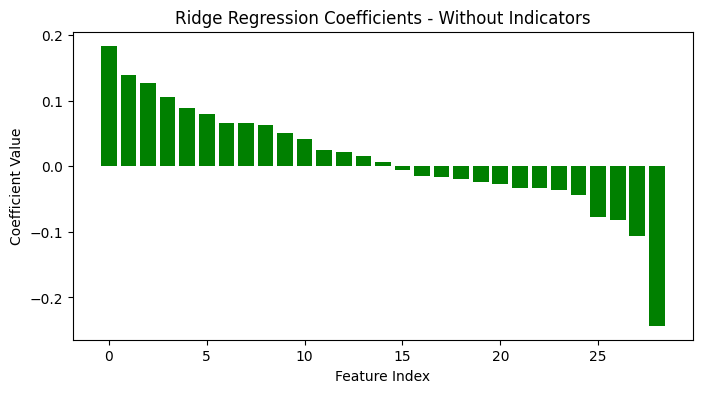

In [506]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(ridge_coefs)), ridge_coefs, color="green")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regression Coefficients - Without Indicators")
plt.show()

In [ ]:
# W INDICATORS ANALYSIS

In [507]:
listing_age = w_indicators_df['listing_age']
listing_age_days = w_indicators_df['listing_age_days']

w_data = w_indicators_df.copy()
cols = ['listing_age', 'listing_age_days', 'id']
w_data = w_data.drop(columns=cols)

y = listing_age_days
scaler = StandardScaler()
X_scaled = scaler.fit_transform(w_data)

X_scaled[:5]

array([[ 2.29833302, -0.61166642, -0.55417403, -0.52745056, -0.36215444,
        -1.16622473,  1.16622473,  2.03271984, -1.00566454, -0.65826883,
         1.3450941 , -0.62315893, -0.07358874, -0.0391179 , -0.02806609,
         3.69187473, -0.35270879, -1.14527991, -0.32038708, -0.12877598,
        -0.09235501, -0.05916145,  0.57946498, -0.34227643, -0.34126264,
        -0.12765677, -0.12230715, -0.08106219, -0.07011654, -0.86720715,
         0.92709011, -0.18467603,  1.17974176,  1.5461268 , -0.17205497],
       [ 2.29833302, -0.61166642, -0.55417403, -0.52745056, -0.36215444,
        -1.16622473,  1.16622473,  2.03271984, -1.00566454, -0.65826883,
        -0.74344241,  1.60472707, -0.07358874, -0.0391179 , -0.02806609,
         3.69187473, -0.35270879, -1.14527991, -0.32038708, -0.12877598,
        -0.09235501, -0.05916145,  0.57946498, -0.34227643, -0.34126264,
        -0.12765677, -0.12230715, -0.08106219, -0.07011654, -0.86720715,
         0.92709011, -0.18467603,  1.17974176, -0.

In [508]:
ridge_coefs = []
for a in grid:
    m = Ridge(alpha=a, fit_intercept=True)
    m.fit(X_scaled, y)
    ridge_coefs.append(m.coef_)

ridge_coefs = np.vstack(ridge_coefs)  # (n_alphas, n_features)
ridge_coefs.shape

(100, 35)

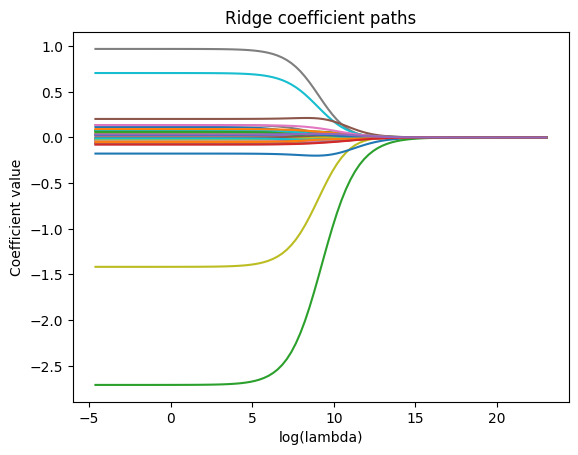

In [509]:
plt.figure()
for j in range(ridge_coefs.shape[1]):
    plt.plot(np.log(grid), ridge_coefs[:, j])
plt.xlabel("log(lambda)")
plt.ylabel("Coefficient value")
plt.title("Ridge coefficient paths")
plt.show()

In [510]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, listing_age_days, test_size=0.2, random_state=42, shuffle=True
)

X_train.shape, X_test.shape

((51836, 35), (12960, 35))

In [511]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)

# RidgeCV chooses alpha that minimizes CV error
ridge_cv = RidgeCV(alphas=grid, cv=kf, fit_intercept=True, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train, y_train)
best_alpha_ridge = ridge_cv.alpha_

print("Best alpha selected:", best_alpha_ridge)


Best alpha selected: 32.745491628777316


In [512]:
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_pred = ridge.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(36.91324791116405, 0.05332365093242686)

In [513]:
ridge_full_best = Ridge(alpha=best_alpha_ridge, fit_intercept=True).fit(X_scaled, y)
ridge_coefs = pd.Series(ridge_full_best.coef_, index=w_data.columns).sort_values(ascending=False)
ridge_coefs

glassdoor                     0.966006
linkedin                      0.702611
sponsored                     0.203203
jt_fulltime                   0.135610
job_level_associate           0.135116
int_yearly                    0.113450
jt_temporary                  0.091710
int_hourly                    0.083182
jt_contract                   0.079722
int_weekly                    0.071932
in                            0.071873
job_level_na                  0.060638
jt_parttime                   0.051342
pst                           0.036120
desc_timeline                 0.033417
range_salary                  0.027797
bos_msa                       0.021079
job_level_director            0.001082
int_monthly                  -0.005675
no_salary                    -0.009839
ny_msa                       -0.021079
job_level_internship         -0.021452
int_daily                    -0.027864
rt                           -0.029144
fi                           -0.029602
remote                   

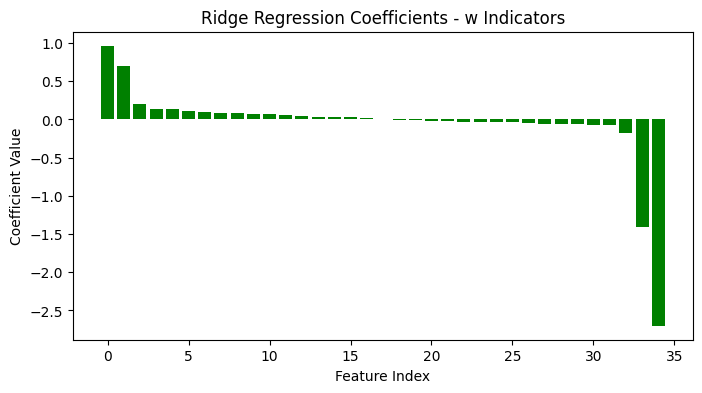

In [514]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(ridge_coefs)), ridge_coefs, color="green")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regression Coefficients - w Indicators")
plt.show()

In [515]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("Model score (R^2):", r2)

MSE: 36.91324791116405
Model score (R^2): 0.05332365093242686


In [516]:
lasso_coefs = []
for a in grid:
    m = Lasso(alpha=a, fit_intercept=True, max_iter=200000)
    m.fit(X_train, y_train)
    lasso_coefs.append(m.coef_)
lasso_coefs = np.vstack(lasso_coefs)
lasso_coefs.shape

(100, 35)

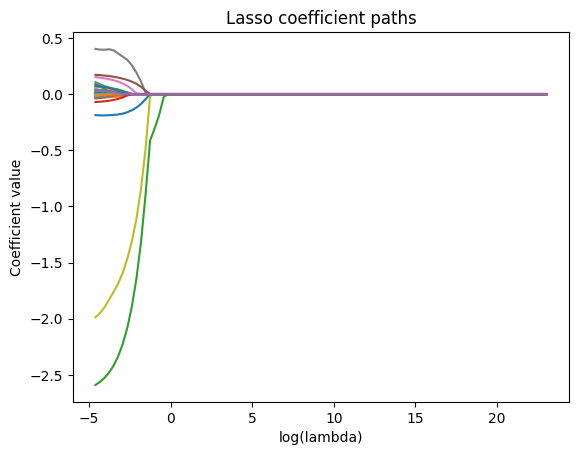

In [517]:
plt.figure()
for j in range(lasso_coefs.shape[1]):
    plt.plot(np.log(grid), lasso_coefs[:, j])
plt.xlabel("log(lambda)")
plt.ylabel("Coefficient value")
plt.title("Lasso coefficient paths")
plt.show()

In [518]:
lasso_cv = LassoCV(alphas=grid, cv=kf, fit_intercept=True, max_iter=200000, random_state=0)
lasso_cv.fit(X_train, y_train)

best_alpha_lasso = lasso_cv.alpha_
best_alpha_lasso

np.float64(0.01)

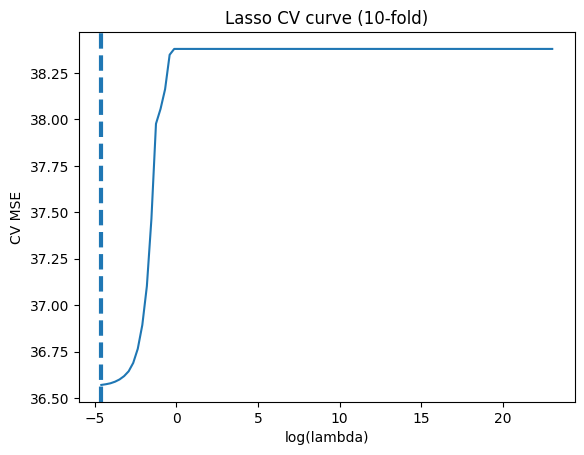

36.926480168674104

In [519]:
# CV curve (mean MSE vs log(lambda))
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure()
plt.plot(np.log(lasso_cv.alphas_), mean_mse)
plt.axvline(np.log(best_alpha_lasso), linestyle="--", linewidth=3)
plt.xlabel("log(lambda)")
plt.ylabel("CV MSE")
plt.title("Lasso CV curve (10-fold)")
plt.show()

lasso_best = Lasso(alpha=best_alpha_lasso, fit_intercept=True, max_iter=200000, random_state=0).fit(X_train, y_train)
mse_lasso_best = mean_squared_error(y_test, lasso_best.predict(X_test))
mse_lasso_best

In [520]:
lasso = Lasso(alpha=best_alpha_lasso)
ridge.fit(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_pred = ridge.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(36.91324791116405, 0.05332365093242686)

lasso_full_best = Lasso(alpha=best_alpha_lasso, fit_intercept=True, max_iter=200000, random_state=0).fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_full_best.coef_, index=w_data.columns).sort_values(ascending=False)
lasso_coefs

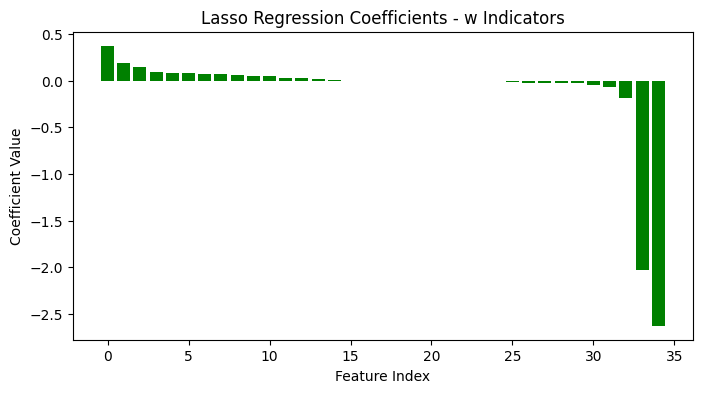

In [522]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(lasso_coefs)), lasso_coefs, color="green")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Coefficients - w Indicators")
plt.show()

In [1]:
# REGRESSIONS
from sklearn.linear_model import LinearRegression

In [105]:
reg_wo_df = baseline_df.copy()
reg_w_df = baseline_df.copy()

In [106]:
platforms = {"glassdoor": 1, "indeed": 2, "linkedin": 3}
sectors = {"FI": 1, "HSA": 2, "IN": 3, "PST": 4, "RT": 5}
job_types = {"fulltime": 1, "parttime": 2, "contract": 3, "internship": 4}
job_levels = {"mid-senior level": 1, "entry level": 2, "director": 3, "associate": 4, "executive": 5, "internship": 6, "na": 0}

salary_formats = {"no_salary": 1, "base_salary": 2, "range_salary": 3}
desc_formats = {"none": 1, "reporting": 2, "timeline": 3, "both": 4}

In [107]:
# operationalize platform
for p in platforms:
    reg_w_df.loc[reg_w_df['site'] == p, "platform"] = platforms[p]

# operationalize market
for m in ["NY", "MA"]:
    reg_w_df.loc[reg_w_df['market'] == m, "msa"] = 1 if m == "NY" else 0

# operationalize by sector
for s in sectors:
    reg_w_df.loc[reg_w_df['sector'] == s, "sector_code"] = sectors[s]

# operationalize job type
reg_w_df.loc[reg_w_df['job_type'].notna() | reg_w_df['job_type'].isna(), "job_type_code"] = 0
for jt in job_types:
    reg_w_df.loc[reg_w_df['job_type'] == jt, "job_type_code"] = job_types[jt]

# operationalize sponsored vs organic listings
reg_w_df.loc[reg_w_df['listing_type'] == "sponsored", "listing_type_code"] = 1
reg_w_df.loc[reg_w_df['listing_type'] != "sponsored", "listing_type_code"] = 0

# operationalize job level
for jl in job_levels:
    if jl == "na":
        reg_w_df.loc[reg_w_df['job_level'].isna(), "job_level_code"] = job_levels[jl]
        reg_w_df.loc[reg_w_df['job_level'] == "not applicable", "job_level_code"] = job_levels[jl]
    else:
        reg_w_df.loc[reg_w_df['job_level'] == jl, "job_level_code"] = job_levels[jl]

In [108]:
today = datetime.datetime.now().strftime("%Y-%m-%d")
today_date_obj = datetime.datetime.strptime(today, "%Y-%m-%d")
listing_age_days = []
listing_ages = []

for i in range(len(wo_indicators_df)):
    date_posted = datetime.datetime.strptime(wo_indicators_df.at[i, 'date_posted'], "%Y-%m-%d")
    listing_age = today_date_obj - date_posted
    days_old = int(str(listing_age).split(" ")[0])
    listing_age_days.append(days_old)

    weeks_old = days_old // 7
    listing_ages.append(weeks_old)

reg_wo_df = reg_wo_df.assign(listing_age_days = listing_age_days, listing_age = listing_ages)
reg_w_df = reg_w_df.assign(listing_age_days = listing_age_days, listing_age = listing_ages)

reg_w_df['listing_age'].value_counts()

listing_age
5    23123
4    21867
3    11815
6     7984
2        7
Name: count, dtype: int64

In [109]:
# operationalize salary disclosure
reg_w_df.loc[reg_w_df['min_amount'].isna(), 'salary_disclosed'] = 0
reg_w_df.loc[reg_w_df['min_amount'].notna(), 'salary_disclosed'] = 1

reg_w_df.loc[reg_w_df['min_amount'] == reg_w_df['max_amount'], "salary_format_code"] = salary_formats["base_salary"]
reg_w_df.loc[reg_w_df['min_amount'] != reg_w_df['max_amount'], "salary_format_code"] = salary_formats["range_salary"]
reg_w_df.loc[reg_w_df['min_amount'].isna() & reg_w_df['max_amount'].isna(), "salary_format_code"] = salary_formats["no_salary"]

# operationalize link to company website as a binary variable
reg_w_df.loc[reg_w_df['job_url_direct'].isna(), 'link_to_company_web'] = 0
reg_w_df.loc[reg_w_df['job_url_direct'].notna(), 'link_to_company_web'] = 1

# operationalize description specificity variable
reporting_keywords = ["report to", "department"]
timeline_keywords = ["start date", "hiring immediately", "applications close"]

reg_w_df.loc[reg_w_df['description'].str.contains('|'.join(timeline_keywords), 
            case=False, na=False), 'desc'] = desc_formats["timeline"]
reg_w_df.loc[reg_w_df['description'].str.contains('|'.join(timeline_keywords), 
            case=False, na=False), 'desc'] = desc_formats["reporting"]
reg_w_df.loc[reg_w_df['description'].str.contains('|'.join(timeline_keywords)) &
             reg_w_df['description'].str.contains('|'.join(reporting_keywords), 
                                                  case=False, na=False), 'desc'] = desc_formats["both"]
reg_w_df.loc[reg_w_df['desc'].isna(), 'desc'] = desc_formats["none"]

In [110]:
cols_to_drop = ['description', 'site', 'job_url', 'job_url_direct', 'title', 'company',
                'location', 'date_posted', 'job_type', 'salary_source', 'interval', 'min_amount',
                'max_amount', 'is_remote', 'job_level', 'job_function', 'listing_type',
                'company_industry', 'company_num_employees', 'company_revenue',
                'sector', 'occupation', 'market', 'date_scraped', 'salary_format_code', 'msa']


In [111]:
reg_w_df = reg_w_df.drop(cols_to_drop, axis=1, errors='ignore')
reg_w_df

,id,platform,sector_code,job_type_code,listing_type_code,job_level_code,listing_age_days,listing_age,salary_disclosed,link_to_company_web,desc
0,gd-1010056379744,1.0,1.0,0.0,1.0,0.0,40,5,1.0,0.0,1.0
1,gd-1010056098752,1.0,1.0,0.0,1.0,0.0,40,5,1.0,0.0,1.0
2,gd-1010056244526,1.0,1.0,0.0,1.0,0.0,40,5,1.0,0.0,1.0
3,gd-1010056045908,1.0,1.0,0.0,1.0,0.0,40,5,1.0,0.0,1.0
4,gd-1010055442989,1.0,1.0,0.0,1.0,0.0,41,5,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
64791,li-4389423105,3.0,5.0,1.0,0.0,2.0,22,3,0.0,0.0,1.0
64792,li-4389438416,3.0,5.0,2.0,0.0,2.0,22,3,0.0,0.0,1.0
64793,li-4389445330,3.0,5.0,2.0,0.0,0.0,22,3,0.0,0.0,1.0
64794,li-4389449386,3.0,5.0,2.0,0.0,2.0,22,3,0.0,0.0,1.0


In [112]:
reg_w_df.to_csv(f"{data_path}/reg_w_df.csv", index=False)

In [43]:
train_data = reg_w_df.copy()
train_data['listing_age_days'] = np.log(train_data['listing_age_days'])
train_X = train_data.drop(['listing_age_days', 'listing_age', 'id'], axis=1, errors='ignore')
train_y = train_data['listing_age_days']

train_X

,platform,sector_code,job_type_code,job_level_code,salary_disclosed,link_to_company_web,desc
0,1.0,1.0,1.0,7.0,1.0,0.0,1.0


In [47]:
model = LinearRegression().fit(train_X, train_y)
r2 = model.score(train_X, train_y)

print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")
print(f"coefficient of determination: {r2}")

intercept: 3.6888794541139363
slope: [0. 0. 0. 0. 0. 0. 0.]
coefficient of determination: nan


c:\Users\maggi\anaconda3\envs\ghostjobs\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
